In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,SystemMessage
from dotenv import load_dotenv
from pydantic import BaseModel,Field

In [39]:
load_dotenv()

generator_llm=ChatGroq(model = "openai/gpt-oss-20b")
evaluator_llm=ChatGroq(model = "openai/gpt-oss-20b")
optimizer_llm=ChatGroq(model = "openai/gpt-oss-120b")

In [54]:
import operator

class MyState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["Approved","Needs Improvement"]
    feedback:str
    iteration:int
    max_iteration:int
    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]


In [69]:
class EvaluateSchema(BaseModel):
    evaluation: Literal[
        "Approved",
        "Needs Improvement"
    ] = Field(description="Evaluation result")

    feedback: str = Field(
        description="Brief feedback in maximum 30 words"
    )

In [70]:
evaluator_schema_llm=evaluator_llm.with_structured_output(EvaluateSchema)

In [71]:
def generate_tweet(state:MyState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    result=generator_llm.invoke(messages).content
    return {"tweet":result,
            "tweet_history":[result]}



def evaluate_tweet(state:MyState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

""")
]
    result=evaluator_schema_llm.invoke(messages)
    return {"evaluation":result.evaluation,
            "feedback":result.feedback,
            "feedback_history":[result.feedback]}   


def optimize_tweet(state:MyState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    result=optimizer_llm.invoke(messages).content 
    iteration=state["iteration"]+1
    return {"tweet":result,
            "iteration":iteration,
            "tweet_history":[result]}   

def route_evaluation(state:MyState)->Literal["Approved","Needs Improvement"]:
    if state["evaluation"]=="Approved" or state["iteration"]>=state["max_iteration"]:
        return "Approved"
    else:
        return "Needs Improvement"



In [72]:
graph=StateGraph(MyState)

graph.add_node("generation",generate_tweet)
graph.add_node("evaluation",evaluate_tweet)
graph.add_node("optimization",optimize_tweet)

graph.add_edge(START,"generation")
graph.add_edge("generation","evaluation")
graph.add_conditional_edges("evaluation",route_evaluation,{"Approved":END,"Needs Improvement":"optimization"})
graph.add_edge("optimization","evaluation")

workflow=graph.compile()


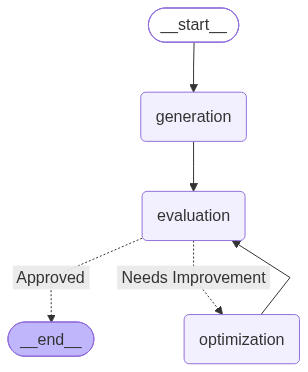

In [73]:
workflow

In [76]:
initial_state={
    "topic":"indian railway",
    "iteration":1,
    "max_iteration":5
}

In [77]:
result=workflow.invoke(initial_state)

In [78]:
result

{'topic': 'indian railway',
 'tweet': 'Indian railways: where the timetable is just a suggestion, the seat is a myth, and the train stops for 5 minutes to let you check your phone. Still the only place where a 6‑hour journey feels like a 30‑minute workout. 🚂😂',
 'evaluation': 'Approved',
 'feedback': 'Solid, relatable humor; fresh twist on phone breaks; punchy enough; good virality. Keeps tweet format clean and engaging.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Indian railways: where the timetable is just a suggestion, the seat is a myth, and the train stops for 5 minutes to let you check your phone. Still the only place where a 6‑hour journey feels like a 30‑minute workout. 🚂😂'],
 'feedback_history': ['Solid, relatable humor; fresh twist on phone breaks; punchy enough; good virality. Keeps tweet format clean and engaging.']}